# Layer 1 in practice: the cosmology

This notebook executes the material of {doc}`../layer1_cosmology`: the
parameter container and its density budget, the neutrinos, the background and
the distances, the linear power spectrum, the amplitude and the growth, and
their derivatives.
It runs on a `pip install` of `ggah_mod` plus `matplotlib`; the last section
compares `emu_pk` with CLASS when `classy` is installed, and is skipped
otherwise.
The outputs shown were produced by the versions printed in the first cell.

In [1]:
import jax
jax.config.update("jax_enable_x64", True)   # before the first ggah_mod import

import importlib.util
from importlib.metadata import version

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import emu_pk
import ggah_mod
from ggah_mod.cosmology import (PLANCK18, Cosmology, angular_diameter_distance,
                                comoving_distance, comoving_volume_element,
                                distance_modulus, growth_factor,
                                growth_scale_spread, hubble_e,
                                ln10A_s_for_sigma8, luminosity_distance,
                                make_pk, s8, sigma8)
from ggah_mod.cosmology.background import nu_density_shape, transverse_distance
from ggah_mod.cosmology.growth import f_sigma8, growth_rate

HAVE_CLASS = importlib.util.find_spec("classy") is not None
plt.rcParams.update({"figure.dpi": 90, "figure.figsize": (6.4, 4.0),
                     "axes.grid": True, "grid.alpha": 0.3})
print(f"ggah_mod {version('ggah_mod')}, emu_pk {version('emu_pk')}, "
      f"jax {jax.__version__}; CLASS available: {HAVE_CLASS}")

ggah_mod 1.0.0, emu_pk 2.0.1, jax 0.10.2; CLASS available: True


## The parameter container

A `Cosmology` has eleven fields.
Ten are differentiable leaves of a JAX pytree; the neutrino ordering is static.
`PLANCK18` differs from a container built with no arguments in one field, the
ordering, because the *Planck* 2018 baseline put its 0.06 eV in one massive state.

In [2]:
default = Cosmology.create()
for name in ("Omega_m", "Omega_b", "h", "n_s", "ln10A_s", "sum_mnu", "w0", "wa",
             "Omega_k", "T_cmb", "nu_hierarchy"):
    print(f"{name:13s} {getattr(PLANCK18, name)!s:>12s} {getattr(default, name)!s:>12s}")

Omega_m               0.31         0.31
Omega_b             0.0493       0.0493
h                   0.6736       0.6736
n_s                 0.9649       0.9649
ln10A_s              3.044        3.044
sum_mnu               0.06         0.06
w0                    -1.0         -1.0
wa                     0.0          0.0
Omega_k                0.0          0.0
T_cmb               2.7255       2.7255
nu_hierarchy    degenerate       normal


The derived densities close one budget, $\Omega_\gamma + \Omega_{\rm b} +
\Omega_{\rm cdm} + \Omega_\nu^{\rm nr} + \Omega_\nu^{\rm r} + \Omega_k +
\Omega_{\rm DE} = 1$, and $\Omega_{\rm m}$ contains the neutrinos' rest mass.

In [3]:
c = PLANCK18
terms = {"Omega_gamma": c.Omega_gamma, "Omega_b": c.Omega_b, "Omega_cdm": c.Omega_cdm,
         "Omega_nu (rest mass)": c.Omega_nu, "Omega_nu_r": c.Omega_nu_r,
         "Omega_k": c.Omega_k, "Omega_de": c.Omega_de}
for name, value in terms.items():
    print(f"{name:22s} {float(value):.8e}")
print(f"{'sum - 1':22s} {float(sum(terms.values())) - 1:.1e}")
print(f"Omega_m - (Omega_b + Omega_cdm + Omega_nu) = "
      f"{float(c.Omega_m - c.Omega_b - c.Omega_cdm - c.Omega_nu):.1e}")
print(f"f_nu = {float(c.f_nu):.5f},  rho_cold/rho_matter = {float(c.rho_cold / c.rho_matter):.5f}")

Omega_gamma            5.45024000e-05
Omega_b                4.93000000e-02
Omega_cdm              2.59280305e-01
Omega_nu (rest mass)   1.41969506e-03
Omega_nu_r             7.03608482e-07
Omega_k                0.00000000e+00
Omega_de               6.89944794e-01
sum - 1                0.0e+00
Omega_m - (Omega_b + Omega_cdm + Omega_nu) = -3.5e-18
f_nu = 0.00458,  rho_cold/rho_matter = 0.99542


$\sigma_8$ and $S_8$ are outputs. Asking for either as an input raises, and the
message names the way to start from a $\sigma_8$.

In [4]:
try:
    Cosmology.create(S8=0.8)
except TypeError as err:
    print(err)

'S8' is not an input to this package.  The amplitude is 'ln10A_s' and sigma8/S8 are derived from the spectrum -- see ggah_mod.cosmology.amplitude.sigma8, .s8.  A cosmology carrying both an amplitude and a sigma8 is over-determined, and which one wins used to depend on which module you were in.  To start from a sigma8, solve for the amplitude once, up front, with amplitude.ln10A_s_for_sigma8().


## Neutrinos

The rest mass $\Omega_\nu^{\rm nr} = \sum m_\nu/(93.14\,{\rm eV}\,h^2)$ depends on
the sum alone; the relativistic part $\Omega_\nu^{\rm r}$, kinetic energy plus
the massless remainder, also depends on how the sum is divided.
At 0.06 eV the lightest state of the normal ordering is still partly
relativistic today.

In [5]:
print(f"{'':11s}{'masses [eV]':>30s}{'rest mass':>12s}{'kinetic':>11s}"
      f"{'remainder':>11s}{'total':>12s}")
for ordering in ("degenerate", "normal"):
    cc = PLANCK18.replace(nu_hierarchy=ordering)
    kinetic = cc.Omega_nu_r - cc.Omega_ur
    masses = np.array2string(np.asarray(cc.nu_masses), precision=5)
    print(f"{ordering:11s}{masses:>30s}{float(cc.Omega_nu):12.5e}{float(kinetic):11.3e}"
          f"{float(cc.Omega_ur):11.3e}{float(cc.Omega_nu_today):12.5e}")

                              masses [eV]   rest mass    kinetic  remainder       total


degenerate               [0.02 0.02 0.02] 1.41970e-03  6.492e-07  5.440e-08 1.42040e-03
normal          [0.00095 0.00871 0.05035] 1.41970e-03  4.482e-06  5.440e-08 1.42423e-03


The mean energy of the massive states relative to massless,
$S_\nu(z) = \tfrac13\sum_j F\big(y_j/(1+z)\big)$, is one while they are
relativistic and $\kappa\bar y/(1+z)$ once they are cold, which turns the
neutrinos' $(1+z)^4$ into the $(1+z)^3$ of matter.

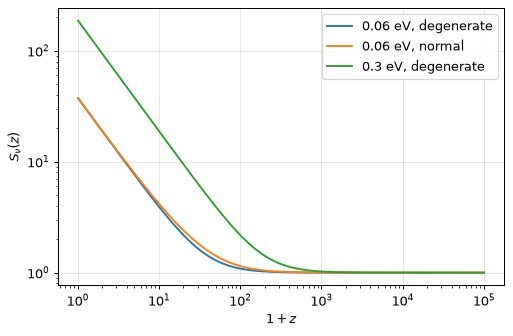

In [6]:
z = np.logspace(-2, 5, 300)
fig, ax = plt.subplots()
for sum_mnu, ordering in ((0.06, "degenerate"), (0.06, "normal"), (0.3, "degenerate")):
    cc = PLANCK18.replace(sum_mnu=sum_mnu, nu_hierarchy=ordering)
    ax.loglog(1 + z, nu_density_shape(z, cc), label=f"{sum_mnu} eV, {ordering}")
ax.set(xlabel="$1+z$", ylabel=r"$S_\nu(z)$")
ax.legend();

## Background expansion and distances

All distances are in $h^{-1}$Mpc, comoving; the distance modulus uses
$D_{\rm L}$ in Mpc.

mu(z=1) = 44.170817110899456 mag; dV/dz/dOmega(z=1) = 8898251068.634771 (h^-1 Mpc)^3 / sr


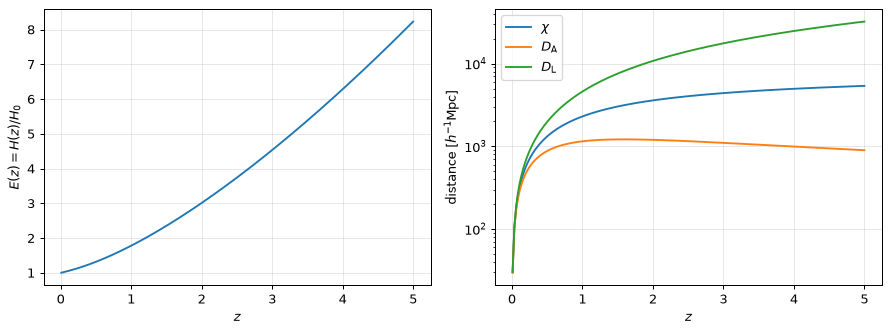

In [7]:
z = np.linspace(0.01, 5.0, 200)
fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.8))
a0.plot(z, hubble_e(z, PLANCK18))
a0.set(xlabel="$z$", ylabel="$E(z) = H(z)/H_0$")
for f, label in ((comoving_distance, r"$\chi$"), (angular_diameter_distance, r"$D_{\rm A}$"),
                 (luminosity_distance, r"$D_{\rm L}$")):
    a1.semilogy(z, f(z, PLANCK18), label=label)
a1.set(xlabel="$z$", ylabel=r"distance [$h^{-1}$Mpc]")
a1.legend()
fig.tight_layout()
print("mu(z=1) =", float(distance_modulus(1.0, PLANCK18)[0]), "mag;",
      "dV/dz/dOmega(z=1) =", float(comoving_volume_element(1.0, PLANCK18)[0]), "(h^-1 Mpc)^3 / sr")

Curvature enters only through the transverse distance $f_K(\chi)$.
The flat case is an interior point of one analytic expression, so at
$\Omega_k = 0$ the transverse distance *is* the radial one, bit for bit.

flat, f_K == chi exactly: True


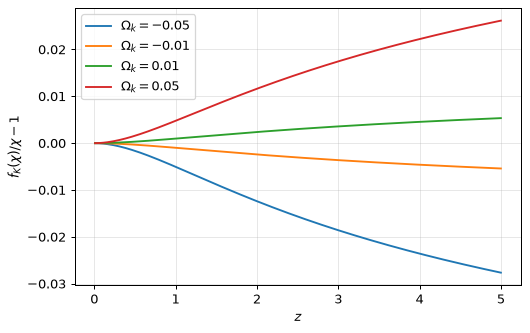

In [8]:
chi = comoving_distance(z, PLANCK18)
print("flat, f_K == chi exactly:", bool(np.all(transverse_distance(chi, PLANCK18) == chi)))

fig, ax = plt.subplots()
for ok in (-0.05, -0.01, 0.01, 0.05):
    cc = PLANCK18.replace(Omega_k=ok)
    chi_c = comoving_distance(z, cc)
    ax.plot(z, transverse_distance(chi_c, cc) / chi_c - 1, label=rf"$\Omega_k = {ok}$")
ax.set(xlabel="$z$", ylabel=r"$f_K(\chi)/\chi - 1$")
ax.legend();

## The linear power spectrum

`emu_pk` returns the total-matter spectrum $P_{\rm m}$ and the cold one
$P_{\rm cb}$; they differ only where massive neutrinos free-stream.
Several redshifts are asked for in one call.

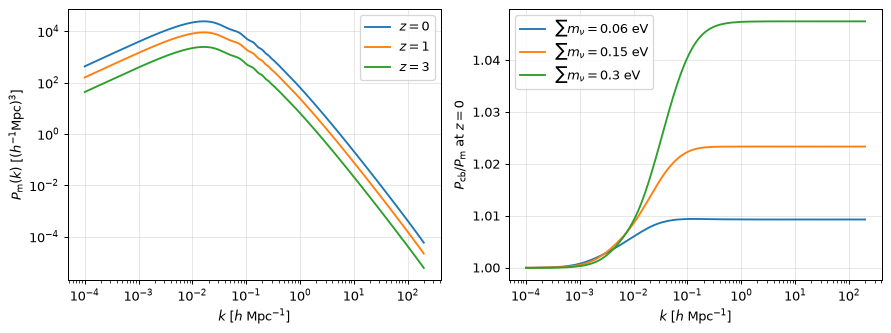

In [9]:
pk = make_pk("emu_pk")
k = np.logspace(-4, np.log10(200.0), 512)
zs = np.array([0.0, 1.0, 3.0])
P_m = pk.pk(k, zs, PLANCK18)

fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.8))
for zi, row in zip(zs, P_m):
    a0.loglog(k, row, label=f"$z = {zi:g}$")
a0.set(xlabel=r"$k$ [$h$ Mpc$^{-1}$]", ylabel=r"$P_{\rm m}(k)$ [$(h^{-1}{\rm Mpc})^3$]")
a0.legend()
for sum_mnu in (0.06, 0.15, 0.3):
    cc = PLANCK18.replace(sum_mnu=sum_mnu)
    a1.semilogx(k, pk.pk_cb(k, 0.0, cc) / pk.pk(k, 0.0, cc), label=rf"$\sum m_\nu = {sum_mnu}$ eV")
a1.set(xlabel=r"$k$ [$h$ Mpc$^{-1}$]", ylabel=r"$P_{\rm cb}/P_{\rm m}$ at $z=0$")
a1.legend()
fig.tight_layout()

The emulator refuses a cosmology outside its training box rather than
extrapolating.

In [10]:
try:
    pk.pk(k, 0.0, PLANCK18.replace(sum_mnu=0.8))
except ValueError as err:
    print(err)

outside the emulator training box, where the network extrapolates with no accuracy guarantee: sum_mnu = 0.8 not in [0, 0.6].


## Amplitude, variance and growth

$\sigma_8$ and $S_8$ are taken on the total-matter spectrum.
The growth factor is a ratio of $\sigma_8$ at two redshifts, and the growth rate
a difference of it in $\ln(1+z)$.

sigma8 = 0.80193,  S8 = 0.81519
sigma(8 Mpc/h) on P_cb = 0.80566


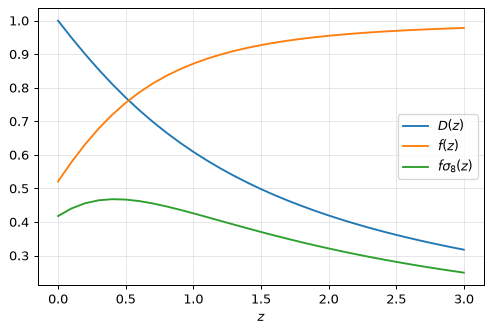

In [11]:
P0 = pk.pk(k, 0.0, PLANCK18)
print(f"sigma8 = {float(sigma8(P0, k)):.5f},  S8 = {float(s8(P0, k, PLANCK18)):.5f}")
print(f"sigma(8 Mpc/h) on P_cb = {float(sigma8(pk.pk_cb(k, 0.0, PLANCK18), k)):.5f}")

z = np.linspace(0.0, 3.0, 31)
D = growth_factor(z, PLANCK18, pk)
f = growth_rate(z, PLANCK18, pk)
fs8 = f_sigma8(z, PLANCK18, pk)
fig, ax = plt.subplots()
ax.plot(z, D, label="$D(z)$")
ax.plot(z, f, label="$f(z)$")
ax.plot(z, fs8, label=r"$f\sigma_8(z)$")
ax.set(xlabel="$z$")
ax.legend();

With massive neutrinos the growth depends on scale, and a scalar $D(z)$ is
ambiguous at the level `growth_scale_spread` reports.
To start from a target $\sigma_8$, solve for the amplitude once and carry it.

In [12]:
for sum_mnu in (0.06, 0.3):
    cc = PLANCK18.replace(sum_mnu=sum_mnu)
    print(f"sum m_nu = {sum_mnu} eV: S(z=0.5) = {float(growth_scale_spread(0.5, cc, pk)):.2e}")

lnA = ln10A_s_for_sigma8(0.78, PLANCK18, pk, k=k)
print(f"ln10A_s = {lnA:.5f} gives sigma8 = "
      f"{float(sigma8(pk.pk(k, 0.0, PLANCK18.replace(ln10A_s=lnA)), k)):.6f}")

sum m_nu = 0.06 eV: S(z=0.5) = 7.52e-04


sum m_nu = 0.3 eV: S(z=0.5) = 2.98e-03
ln10A_s = 2.98854 gives sigma8 = 0.780000


## Derivatives

Everything above is written in `jax.numpy`.
Differentiating the log power spectrum with respect to nine parameters at once
is one `jax.jacfwd`; the amplitude and the tilt are restored in closed form by
`emu_pk`, so $\partial\ln P/\partial\ln(10^{10}A_{\rm s}) = 1$ and
$\partial\ln P/\partial n_{\rm s} = \ln(k/k_{\rm pivot})$ exactly.

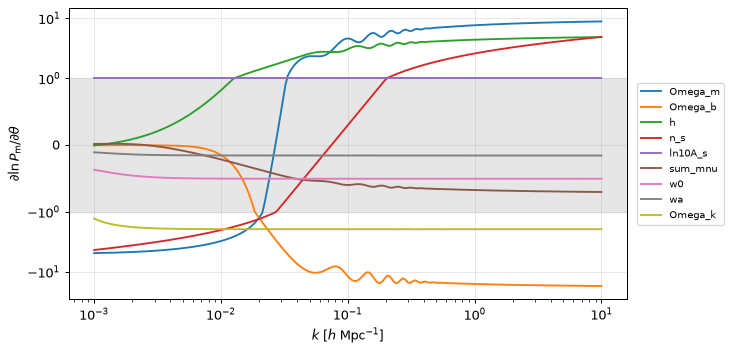

In [13]:
names = ["Omega_m", "Omega_b", "h", "n_s", "ln10A_s", "sum_mnu", "w0", "wa", "Omega_k"]
theta0 = jnp.array([float(getattr(PLANCK18, n)) for n in names])
kk = np.logspace(-3, 1, 200)


def lnP(theta):
    cc = PLANCK18.replace(**dict(zip(names, theta)))
    return jnp.log(pk.pk(kk, 0.0, cc))


J = jax.jacfwd(lnP)(theta0)           # shape (200, 9)

fig, ax = plt.subplots(figsize=(8.0, 4.2))
for i, name in enumerate(names):
    ax.semilogx(kk, J[:, i], label=name)
ax.set(xlabel=r"$k$ [$h$ Mpc$^{-1}$]", ylabel=r"$\partial\ln P_{\rm m}/\partial\theta$",
       )
ax.set_yscale("symlog", linthresh=1.0)
ax.axhspan(-1, 1, color="0.9", zorder=0)   # the symlog axis is linear inside the band
ax.legend(fontsize=8, loc="center left", bbox_to_anchor=(1.01, 0.5));

A central finite difference checks the automatic derivative.

In [14]:
for i, step in ((0, 1e-4), (2, 1e-4), (5, 1e-3)):
    e = jnp.zeros(len(names)).at[i].set(step)
    fd = (lnP(theta0 + e) - lnP(theta0 - e)) / (2 * step)
    print(f"{names[i]:8s} max |autodiff - finite difference| = {float(jnp.max(jnp.abs(J[:, i] - fd))):.1e}")
print("d lnP / d ln10A_s, min and max:", float(J[:, 4].min()), float(J[:, 4].max()))

Omega_m  max |autodiff - finite difference| = 7.2e-07
h        max |autodiff - finite difference| = 7.5e-08


sum_mnu  max |autodiff - finite difference| = 6.5e-06
d lnP / d ln10A_s, min and max: 0.9999999999999999 1.0


## The accurate path: `emu_pk` against CLASS

`emu_pk` was trained on CLASS at CLASS's default precision; the `ACCURATE`
flavour runs CLASS at raised precision.
The ratio below is therefore the emulator's error plus the precision
difference, at the fiducial cosmology.

z = 0: max |emu_pk/CLASS - 1| on 1e-3 < k < 10 = 3.56e-03
z = 1: max |emu_pk/CLASS - 1| on 1e-3 < k < 10 = 3.56e-03


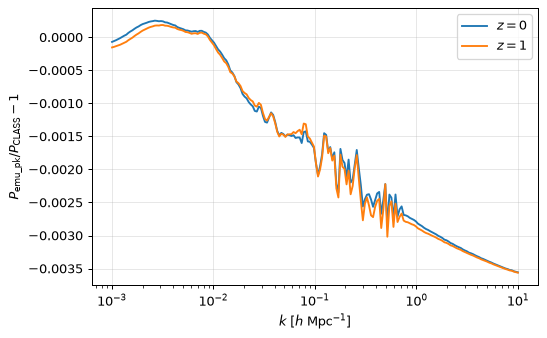

In [15]:
if HAVE_CLASS:
    pk_class = make_pk("class")
    zs = np.array([0.0, 1.0])
    kc = np.logspace(-3, 1, 200)
    P_emu, P_cls = pk.pk(kc, zs, PLANCK18), pk_class.pk(kc, zs, PLANCK18)
    fig, ax = plt.subplots()
    for zi, a, b in zip(zs, P_emu, P_cls):
        ax.semilogx(kc, a / b - 1, label=f"$z = {zi:g}$")
        print(f"z = {zi:g}: max |emu_pk/CLASS - 1| on 1e-3 < k < 10 = {np.max(np.abs(a / b - 1)):.2e}")
    ax.set(xlabel=r"$k$ [$h$ Mpc$^{-1}$]", ylabel=r"$P_{\rm emu\_pk}/P_{\rm CLASS} - 1$")
    ax.legend()
else:
    print("classy is not installed: pip install 'ggah_mod[reference]' to run this cell.")

## Things to try

- Build a cosmology with `nu_hierarchy="inverted"` at 0.06 eV and read the
  error message; then find the smallest sum it accepts.
- Plot $\partial\ln\chi(z)/\partial\theta$ against redshift with `jax.jacfwd`,
  and check that $n_{\rm s}$ and $\ln(10^{10}A_{\rm s})$ do not reach it.
- Compare `growth_factor(..., variant="cold")` with the default at
  $\sum m_\nu = 0.3$ eV.

Next: {doc}`../layer2_halos`, and its {doc}`notebook <layer2_halos>`.